# Introduction
In this report, a set of Ordinary Differential Equations (ODEs) will be derived from a Chemical Reaction Network (CRN). There is a missing parameter that will be determined through a cost-minimisation technique. Disturbances to the model will be added and different controllers formed to introduce setpoint tracking. The report will also discuss the effects of modelling dilution and methods of mitigating the loss of memory as a result.

# Part 1: Determing the Process Model
Assuming spatial homogeneity and that the mixture of reactants is well-interspersed, the Law of Mass Action can be applied to the CRN described by Figure 1 in the brief.

$$\frac{d\left\lbrack X_{1} \right\rbrack}{dt} = 2\beta_{2}\left\lbrack X_{2} \right\rbrack - 2\beta_{1}\left\lbrack X_{1} \right\rbrack^{2}$$

$$\frac{d\left\lbrack X_{2} \right\rbrack}{dt} = \beta_{1}\left\lbrack X_{1} \right\rbrack^{2} - \beta_{2}\left\lbrack X_{2} \right\rbrack - \beta_{3}\left\lbrack X_{2} \right\rbrack$$

$$\frac{d\left\lbrack X_{3} \right\rbrack}{dt} = \beta_{0} - \beta_{4}\left\lbrack X_{3} \right\rbrack - \beta_{5}\left\lbrack X_{3} \right\rbrack$$

$$\frac{d\left\lbrack X_{4} \right\rbrack}{dt} = \beta_{3}\left\lbrack X_{2} \right\rbrack + \beta_{4}\left\lbrack X_{3} \right\rbrack - \beta_{6}\left\lbrack X_{4} \right\rbrack$$

$$\frac{d\left\lbrack X_{5} \right\rbrack}{dt} = \beta_{5}\left\lbrack X_{3} \right\rbrack + \beta_{6}\left\lbrack X_{4} \right\rbrack - \beta_{7}\left\lbrack X_{5} \right\rbrack$$

For the input motif:

$$\frac{d\left\lbrack Z_{1} \right\rbrack}{dt} = \mu - \eta\left\lbrack Z_{1} \right\rbrack$$

There is also an activation of $X_{1}$ by $Z_{1}$:

$$\frac{d\left\lbrack X_{1} \right\rbrack}{dt} = \alpha k\left\lbrack Z_{1} \right\rbrack$$

The full equation can be expressed as a simple sum.

$$\frac{d\left\lbrack X_{1} \right\rbrack}{dt} = \alpha k\left\lbrack Z_{1} \right\rbrack + 2\beta_{2}\left\lbrack X_{2} \right\rbrack - 2\beta_{1}\left\lbrack X_{1} \right\rbrack^{2}$$

The code block below imports the necessary modules and custom class implementing the model.

In [1]:
import numpy as np
from scipy import integrate, optimize
import matplotlib.pyplot as plt
import ODEModel

Assignment = ODEModel.ES97J_2110409_A1()

All parameters are known with the exception of $\beta_{3}$, which can be determined by cost function minimisation. In `assignmentModelCost` (method 5), the setpoint signal is set to match the graph from Figure 1C in the brief. The root mean square error (RMSE) can be calculated by using the calculated values from an ODE solver and the measured values from Table 1 in the brief. SciPy's function `fminbound` can minimise this RMSE by providing the method, a lower bound, and an upper bound as arguments to find $\beta_{3}$.

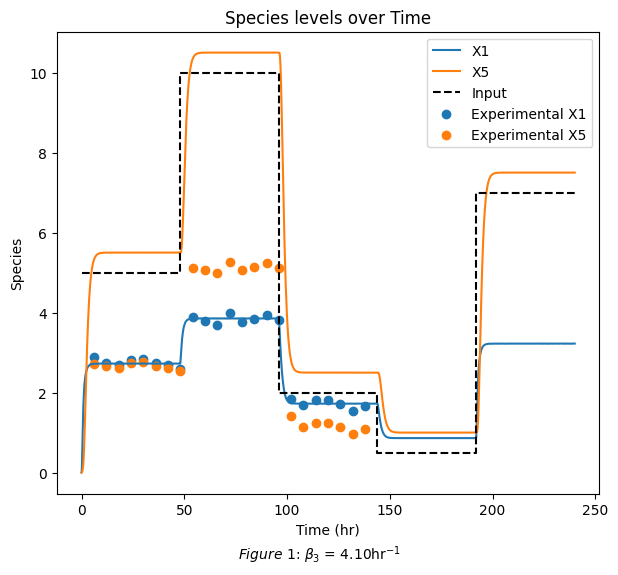

In [2]:
beta3 = optimize.fminbound(Assignment.assignmentModelCost, 0, 20)
Assignment.plotFittedModel(beta3)

$X_{5}$ tracks the input fairly well, though there is an offset of around 0.5. Note that while the cost minimisation has resulted in similar theoretical and experimental values of $X_{1}$, the values of $X_{5}$ differ extensively. This is likely due to random disturbances present that affect reaction rates in the experimental model.

# Part 2: Modelling a Disturbance
$X_{2}$ is subjected to a disturbance $\Delta_{1}$, so its equation needs to be updated. This disturbance is 0 up until $t = 144h$, where it is then modelled as $0.5h^{- 1}$.

$$\frac{d\left\lbrack X_{2} \right\rbrack}{dt} = \left( \beta_{1} + \Delta_{1} \right)\left\lbrack X_{1} \right\rbrack^{2} - \beta_{2}\left\lbrack X_{2} \right\rbrack - \beta_{3}\left\lbrack X_{2} \right\rbrack$$

After the disturbance is applied, $X_{5}$ no longer closely tracks the input, especially for higher levels of $u$ (Figure 2). To better evaluate the effect of $\Delta_{1}$, a range of values between $- 0.9h^{- 1}$ and $1h^{- 1}$ can be trialled (Figure 3).

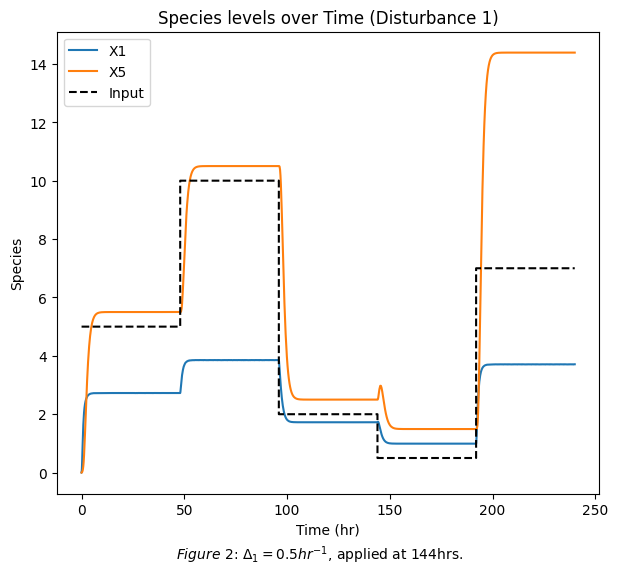

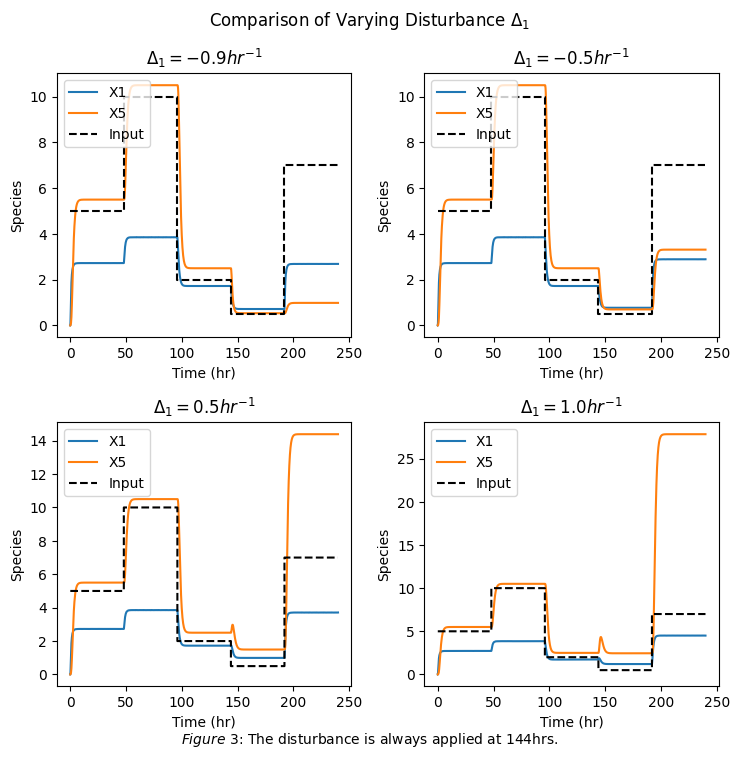

In [3]:
Assignment.plotDist(distOption=1)
Assignment.plotVaryDist(distOption=1)

$X_{5}$ follows a clear trend with the range of disturbances &mdash; negative disturbances always scale $X_{5}$ below its original value and the opposite is true for positive disturbances. The disturbance has a significant effect on the $X_{5}$ concentration levels. There is an initial bump in the levels when $\Delta_{1}$ is positive.

Another disturbance, $\Delta_{2}$, can be introduced. This time it will be modifying $X_{4}$, though it will still be applied at the same time. $\Delta_{1}$ will be set to 0 temporarily to study the effects of $\Delta_{2}$ only.


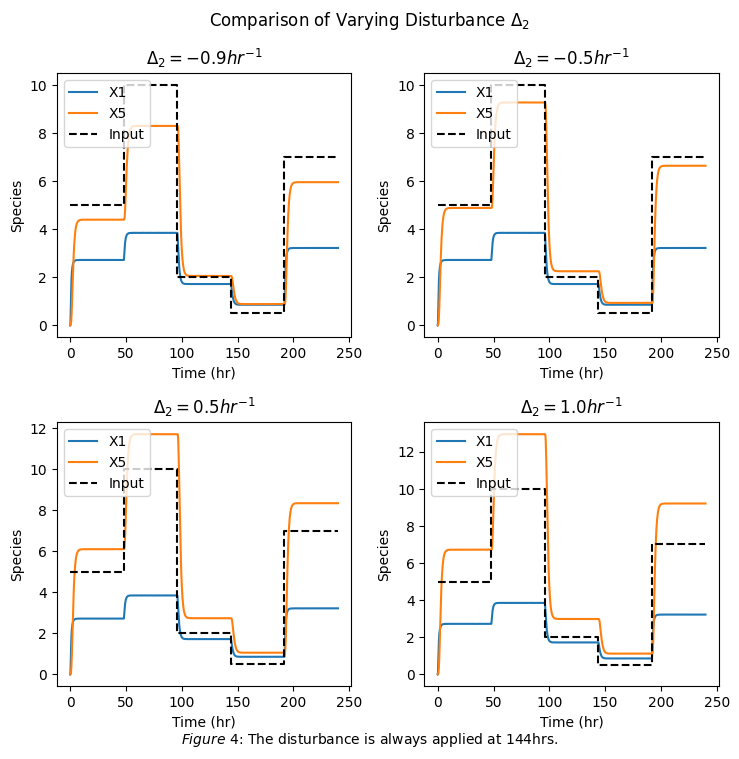

In [4]:
Assignment.plotVaryDist(distOption=2)

After similarly varying $\Delta_{2}$, it can be observed that its effect is not as weighty as $\Delta_{1}$. To observe the efficacy of the controllers, it is suitable to model both disturbances at different times in the model and observe what effects the control action has on them. Keeping $\Delta_{1}$ the same as the initial value ($0.5hr^{-1}$ at 144 hours) and setting $\Delta_{2} = 1hr^{-1}$ results in the plot below (Figure 5).

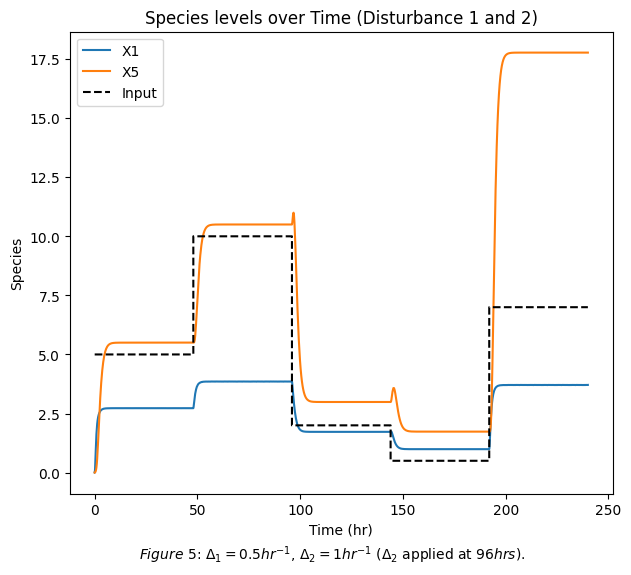

In [5]:
Assignment.plotBothDist()

# Part 3: Introducing Feedback Control
To implement a proportional controller, $u$ is modified to now have a negative feedback term:

$$u = k\left\lbrack Z_{1} \right\rbrack - K\left\lbrack X_{5} \right\rbrack$$

$K$ is the proportional gain that scales with the level of $X_{5}$ negatively, thereby reducing the input as the concentration of $X_{5}$ rises.
After setting $K=1hr^{-1}$ as the brief specifies, the levels of species $X_{1}$ violate a constraint massively (i.e., the levels cannot be below zero).

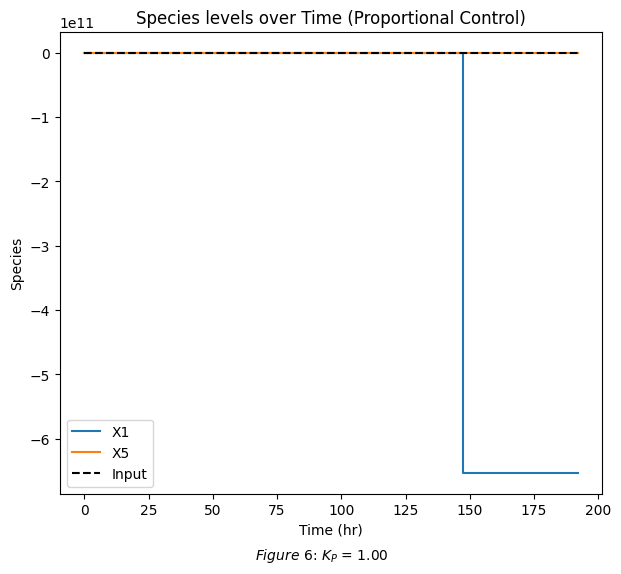

In [6]:
Assignment.plotProportionalControl(Kp=1)

## Integral Absolute Error (IAE)
The integral absolute error is a performance indicator that captures metrics such as the percentage overshoot and rise times. Cost function minimisation can output the optimal parameters to minimise this error. It is a simple calculation which is beneficial, as a multivariate cost function can be slow to minimise. 

Here, an algorithm (differential evolution) to find the _global_ minimum can calculate the optimal $K$. If the levels of any species go below zero, the cost will be scaled upwards depending on how severe the violation is. For example, if $X_{1}$ dips to -0.01, then the incurred penalty would not be as severe as the one incurred by the levels seen in Figure 6.

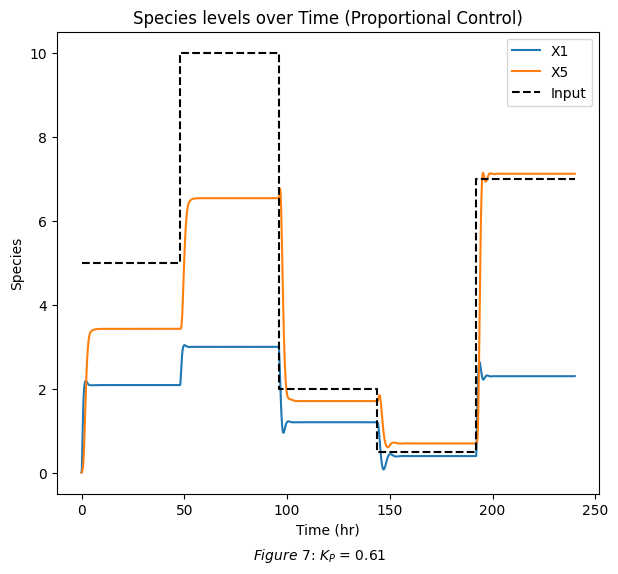

In [7]:
Kp = optimize.differential_evolution(
    Assignment.assignmentModelKpCost,
    bounds=[(0, 5)],
    maxiter=10)
Assignment.plotProportionalControl(Kp=Kp.x[0])

The value of $K=0.61hr^{-1}$ offers the smallest overall IAE. The initial peaks introduced by the disturbances are smaller and the loss of setpoint tracking is restored. This type of control only offers a form of output scaling, however. It is obvious that it is far from perfect; the levels of $X_{5}$ are nowhere near the input for the first few values of $\mu$.

# Part 4: Introducing Integral Control
From the antithetic controller described by Figure 2 in the assignment brief, the new species $Z_{2}$ can be modelled with:

$$\frac{d\left\lbrack Z_{2} \right\rbrack}{dt} = \theta\left\lbrack X_{5} \right\rbrack - \eta_{2}\left\lbrack Z_{2} \right\rbrack\left\lbrack Z_{1} \right\rbrack$$

$Z_{1}$ needs to be modified:

$$\frac{d\left\lbrack Z_{1} \right\rbrack}{dt} = \mu - \eta_{2}\left\lbrack Z_{2} \right\rbrack\left\lbrack Z_{1} \right\rbrack$$

Initial values for $\theta=1hr^{-1}$ and $\eta=0.1hr^{-1}$ are used and the resulting plot is shown in Figure 8 below.

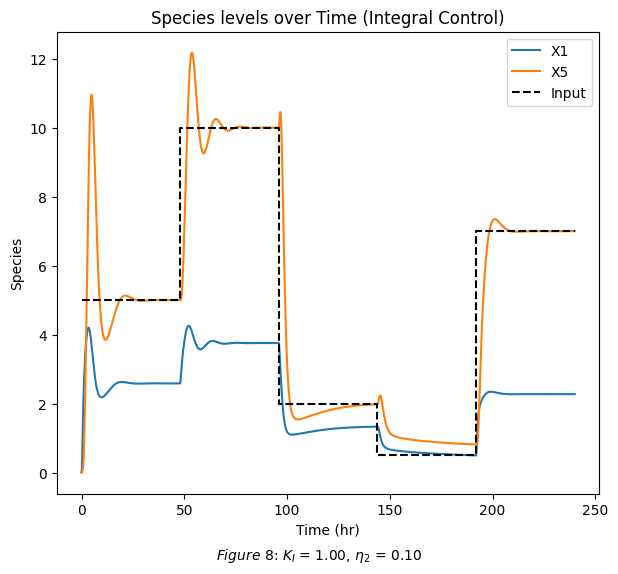

In [8]:
Assignment.plotIntegralControl(theta=1, eta2=0.1)

For the first two setpoints, $X_{5}$ manages to settle at the reference signal before the setpoint changes. However, at the times the disturbances are introduced, $X_{5}$ does not manage to settle at the setpoint. The response after the disturbances is slower with less overshoot/undershoot, especially when compared to before the disturbances. As before with the proportional control, differential evolution can find the optimal $\theta$ _and_ $\eta_{2}$ that minimises the IAE.

Optimization terminated successfully.


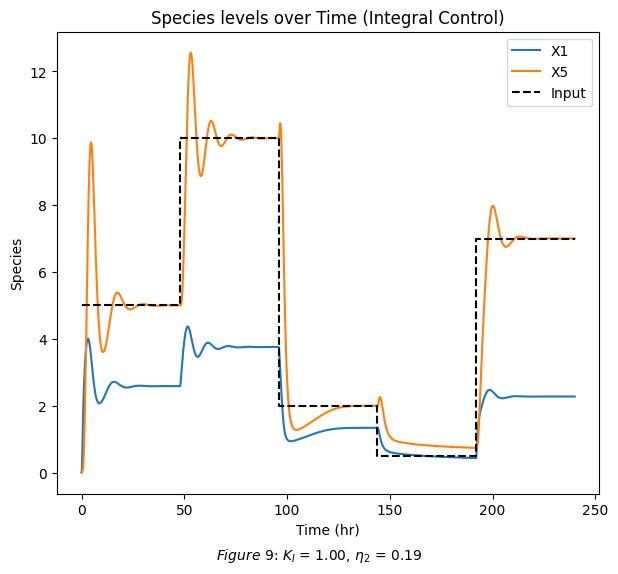

In [9]:
integResult = optimize.differential_evolution(
    Assignment.assignmentModelKICost,
    bounds=[(0,1.5),(0.09,10)], 
    maxiter=40,
)
Assignment.plotIntegralControl(theta=integResult.x[0], eta2=integResult.x[1])
print(integResult.message)

There is minimal improvement to the overall response. The overshoot for the signal $\mu=5$ is reduced, though to the detriment of the successive setpoint changes. Both integral and proportional control on their own do not offer perfect tracking, stability, or strong disturbance rejection.

# Part 5: PI Control for Robust Tracking
To combine both proportional and integral controllers, both equations from parts 3 and 4 can be implemented at the same time. Again, the IAE will be minimised.

Optimization terminated successfully.


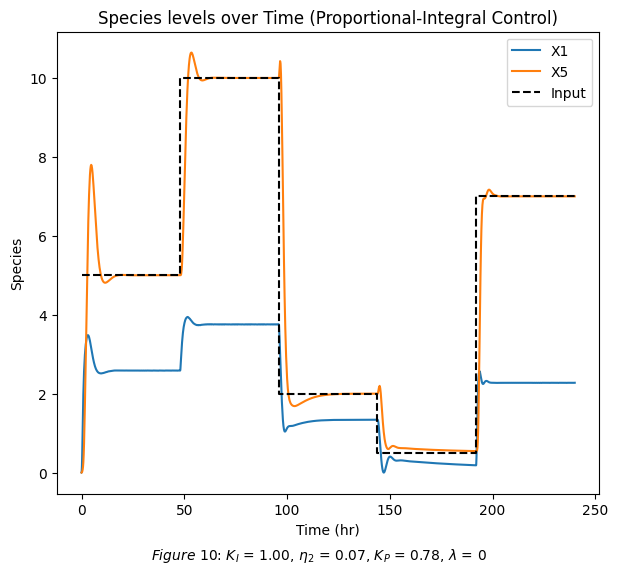

In [10]:
PIResult = optimize.differential_evolution(
    Assignment.assignmentModelKPICost,
    bounds=[(0, 2), (0.01, 1), (0, 1)], # theta, eta_2, K
    maxiter=40,
    args=(0,) # dilution
)
Assignment.plotPIControl(theta=PIResult.x[0], eta2=PIResult.x[1], Kp=PIResult.x[2])
print(PIResult.message)

Figure 10 shows far more satisfactory results. While the overshoot for the first setpoint is still high (compared to the other setpoints), these values of $K$, $\theta$, and $\eta_{2}$ provide the smallest overall IAE for the given ranges. If it is desired, a weight can be applied to the cost function such that it prioritises minimising the IAE for an individual section. However, since there were no design specifications listed, minimising the overall IAE is a good objective.

Note that $X_{5}$ just about reaches the reference where $\mu=0.5$; it was not able to do so with the integral controller. The rise times and settling times are also shorter. So while the disturbances affect $X_{5}$'s ability to track the setpoint, the PI controller succeeds in minimising this.

Instead of tracking $X_{5}$, the model equations can be changed so that the controllers act upon $X_{4} $ instead.

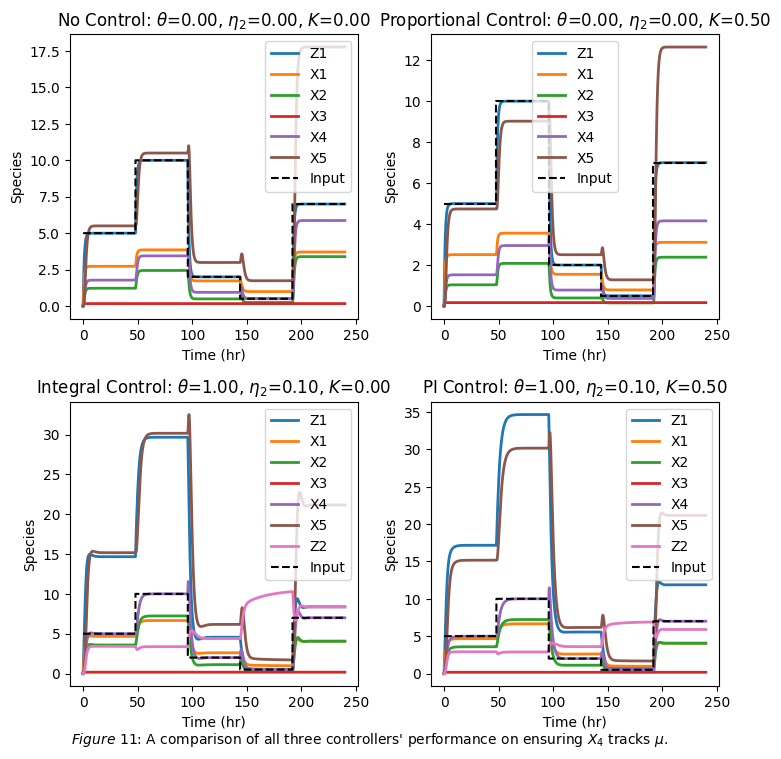

In [11]:
Assignment.plotAllControlX4()

The values for the controllers seen in Figure 11 were not optimised, suitable values were chosen to just observe the efficacy. The proportional controller on its own cannot restore tracking (though with positive feedback it would be possible). Only the controllers with the integral component can restore tracking. Interestingly, $X_{4}$ tracks the reference quite well, even with the addition of the disturbances (the disturbances are the same as prior sections). The proportional component does help reduce whatever overshoot there is.

# Part 6: Incorporating Growth
To incorporate growth, a simple term of $- \lambda\left\lbrack X_{i} \right\rbrack$ can be added to all of the species in the model, where $\lambda=0.05hr^{-1}$.

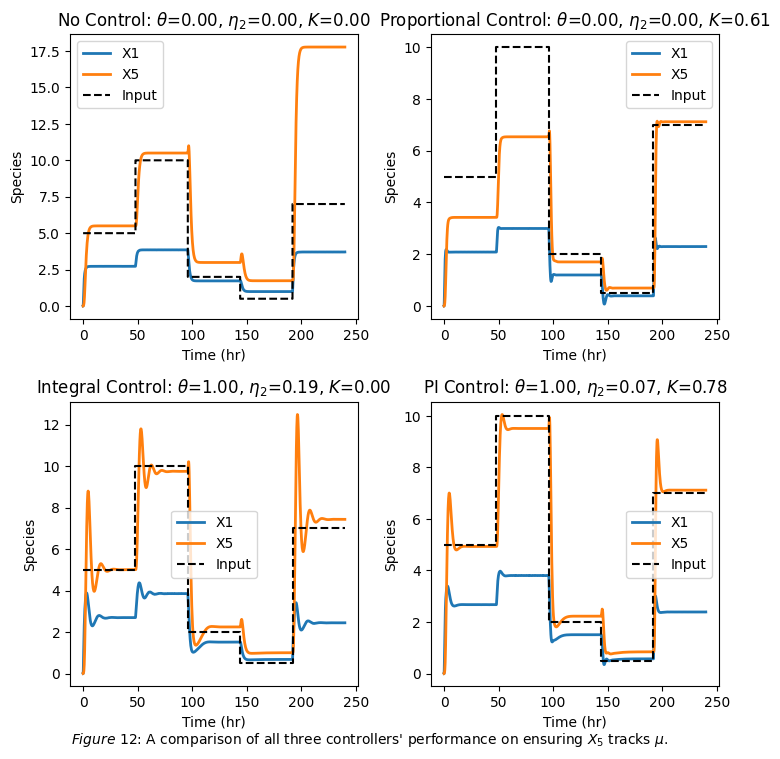

In [12]:
Assignment.plotAllControlX5(theta=[0,0,integResult.x[0],PIResult.x[0]], 
                            eta2=[0,0,integResult.x[1],PIResult.x[1]], 
                            Kp=[0,Kp.x[0],0,PIResult.x[2]], 
                            dilution=0.05)

Using the same calculated values for P, I, and PI control, the effect growth has on the model can be seen in Figure 13. P control remains much the same, however, I control suffers heavily with significantly larger percentage overshoots and loss of reference tracking. PI control curtails this loss in efficacy by restoring some tracking and reducing the overshoot, though it is still not as good as before. Now, the parameters will be retuned while grwoth is included.

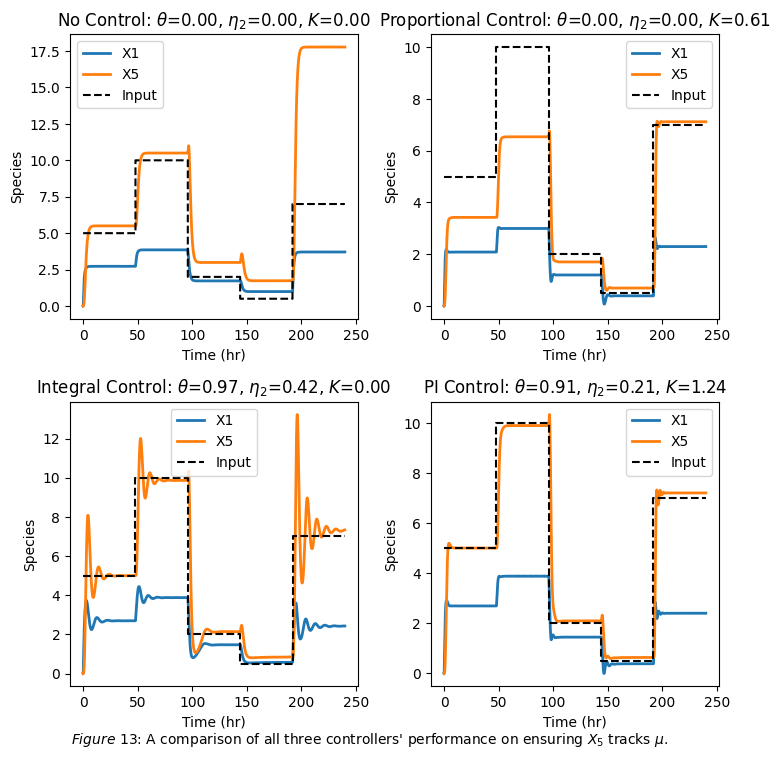

In [13]:
KpG = optimize.differential_evolution(
    Assignment.assignmentModelKpCost,
    bounds=[(0, 5)],
    maxiter=10)

integResultG = optimize.differential_evolution(
    Assignment.assignmentModelKICost,
    bounds=[(0,1.5),(0.09,1)], 
    maxiter=40,
)

PIResultG = optimize.differential_evolution(
    Assignment.assignmentModelKPICost,
    bounds=[(0, 2), (0.01, 1), (0, 2)], # theta, eta_2, K
    maxiter=40,
    args=(0.05,) # dilution
)

Assignment.plotAllControlX5(theta=[0,0,integResultG.x[0],PIResultG.x[0]], 
                            eta2=[0,0,integResultG.x[1],PIResultG.x[1]], 
                            Kp=[0,KpG.x[0],0,PIResultG.x[2]], 
                            dilution=0.05)

Yet again, the I and PI control methods are the ones that change drastically compared to P control. The I control improves its tracking, though becomes far more oscillatory at the final setpoint. PI control restores great performance with strong disturbance rejection, fast rise and settling times, as well as strong reference tracking. Note that there is still some steady-state error in the final setpoint, however.

# Part 7: Biological Realisation

Integral control is a very commonly used method of controlling systems by responding to the accumulation of past error. In the previous sections of the report, an ideal integrated control motif was used to implement integral control in a biological context to return a species' concentration to an intended setpoint (or reference). However, with the implementation of growth in the model, the ideal motif becomes "leaky" and perform worse, as can be seen in part 6. To counteract this, quasi-integral control motifs (Q-ICM) are used (Qian and Del Vecchio, 2018). A quasi-integral motif is one where its control process is faster than the dilution rate.

<figure style="margin-left: 0; margin-right: auto;">
  <img src="imgs/part7_leaky.png" style="width:75%; display:block; margin-left:0;">
  <figcaption style="margin-left:0;">
    <em>Figure 14.</em> Ideal motif (left), leaky motif (middle) and quasi-integral (right) (Qian and Del Vecchio, 2018).
  </figcaption>
</figure>

$\varepsilon$ is a positive (dimensionless) number that is much less than 1 to represent the dynamics of its control being faster.

A real-life example of this Q-ICM is the sRNA-based quasi-integral controller which regulates a protein to adapt to a disturbance, which is what the earlier sections in the report have detailed. The source of the disturbance is the uncertainty in translation rates.

The controller operates through a protein, $p$, which transcriptionally activates the production of a small RNA (sRNA), denoted as $s$. This sRNA is complementary to the mRNA ($m$) encoding the regulated protein. The sRNA and mRNA interact and rapidly degrade together. The concentration of mRNA serves as the control input to the translation process, while a constant upstream transcription factor regulates the mRNA production, acting as the reference input to the controller (Figure 15).

<figure style="margin-left: 0; margin-right: auto;">
  <img src="imgs/part7_realisation.png" style="width:75%; display:block; margin-left:0;">
  <figcaption style="margin-left:0;">
    <em>Figure 15.</em> Real-life version of the Q-ICM (Qian and Del Vecchio, 2018).
  </figcaption>
</figure>

This gene circuit was carried out in practice (in *E. coli*) and the result was "near perfect adaptation" (Huang, Qian and Del Vecchio, 2018).

# References

Huang, H.-H., Qian, Y. and Del Vecchio, D. (2018). A quasi-integral controller for adaptation of genetic modules to variable ribosome demand. *Nature Communications*, \[online\] 9(1), p.5415. doi:https://doi.org/10.1038/s41467-018-07899-z.

Qian, Y. and Del Vecchio, D. (2018). Realizing 'integral control' in living cells: how to overcome leaky integration due to dilution?. *Journal of the Royal Society, Interface*, \[online\] 15(139), p.20170902. doi:https://doi.org/10.1098/rsif.2017.0902.
